
# PRCP-1011-Blood Donation Prediction

In [68]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.metrics import accuracy_score, precision_score
from sklearn.metrics import recall_score, f1_score, roc_auc_score
from sklearn.model_selection import cross_val_score

<b>Load Dataset</b>

In [69]:
df = pd.read_excel("blood_data.xlsx")
df.head()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
0,619,2,50,12500,98,1
1,664,0,13,3250,28,1
2,441,1,16,4000,35,1
3,160,2,20,5000,45,1
4,358,1,24,6000,77,0


<b>Basic Information</b>

In [70]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 6 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   Unnamed: 0                   576 non-null    int64
 1   Months since Last Donation   576 non-null    int64
 2   Number of Donations          576 non-null    int64
 3   Total Volume Donated (c.c.)  576 non-null    int64
 4   Months since First Donation  576 non-null    int64
 5   Made Donation in March 2007  576 non-null    int64
dtypes: int64(6)
memory usage: 27.1 KB


In [71]:
df.describe()

,Unnamed: 0,Months since Last Donation,Number of Donations,Total Volume Donated (c.c.),Months since First Donation,Made Donation in March 2007
count,576.000000,576.000000,576.000000,576.000000,576.000000,576.000000
mean,374.034722,9.439236,5.427083,1356.770833,34.050347,0.239583
std,216.947773,8.175454,5.740010,1435.002556,24.227672,0.427200
min,0.000000,0.000000,1.000000,250.000000,2.000000,0.000000
25%,183.750000,2.000000,2.000000,500.000000,16.000000,0.000000
50%,375.500000,7.000000,4.000000,1000.000000,28.000000,0.000000
75%,562.500000,14.000000,7.000000,1750.000000,49.250000,0.000000
max,747.000000,74.000000,50.000000,12500.000000,98.000000,1.000000


In [72]:
df.shape

(576, 6)

<b>Data Cleaning</b>

In [73]:
df.drop("Unnamed: 0", axis=1, inplace=True)

In [74]:
df.isnull().sum()

Months since Last Donation     0
Number of Donations            0
Total Volume Donated (c.c.)    0
Months since First Donation    0
Made Donation in March 2007    0
dtype: int64

In [75]:
df.duplicated().sum()

np.int64(153)

<b>Exploratory Data Analysis (EDA)</b>

<b>Distribution Plot</b>

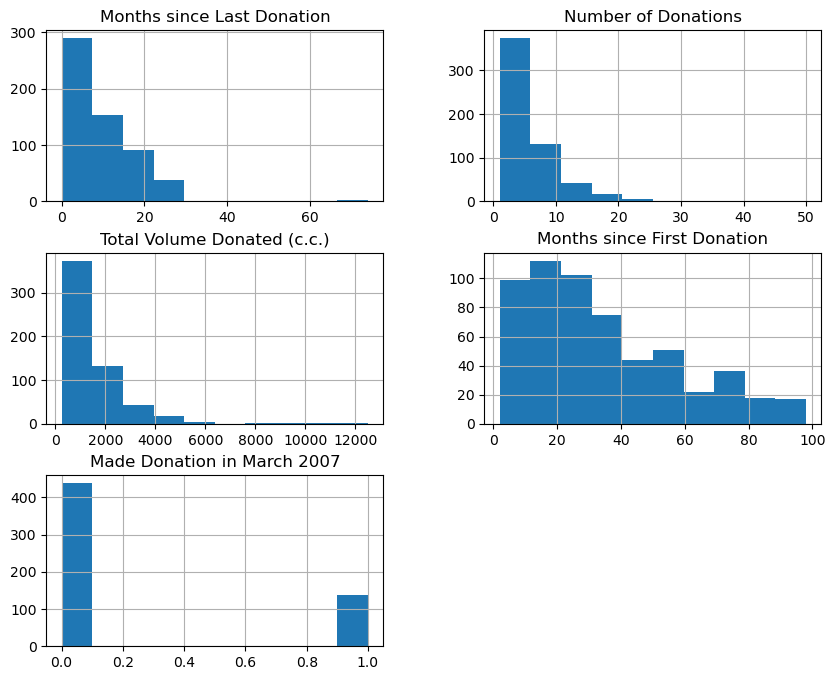

In [76]:
df.hist(figsize=(10,8))
plt.show()

<b>Correlation Heatmap</b>

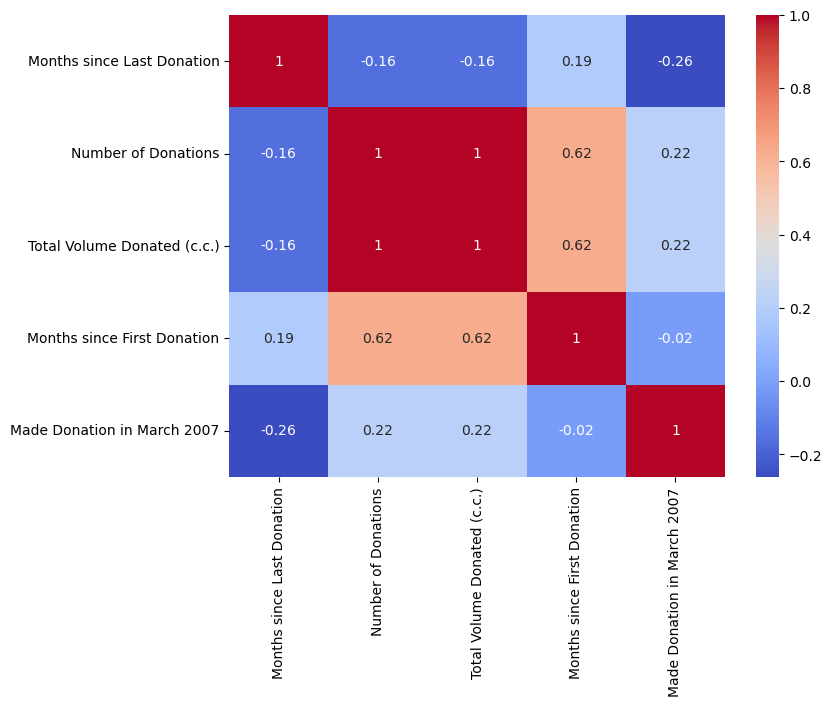

In [77]:
plt.figure(figsize=(8,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.show()

<b>Target Variable Count</b>

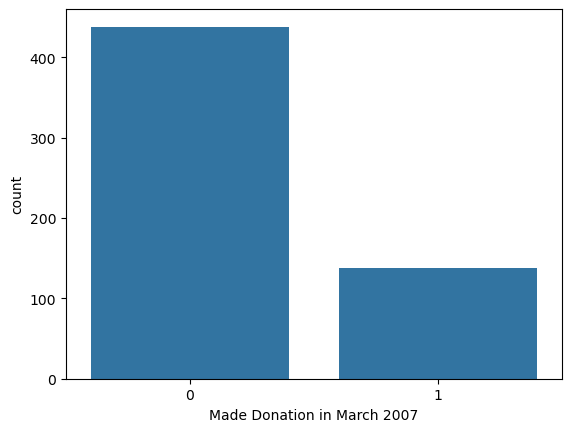

In [78]:
sns.countplot(x='Made Donation in March 2007', data=df)
plt.show()

<b>Feature and Target Separation</b>

In [79]:
X = df.drop('Made Donation in March 2007', axis=1)

y = df['Made Donation in March 2007']

<b>Train Test Split</b>

In [80]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

<b>Feature Scaling</b>

In [81]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

<b>Model Building</b>

<b>Logistic Regression</b>

In [82]:
lr = LogisticRegression()

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

<b>Decision Tree</b>

In [83]:
dt = DecisionTreeClassifier()

dt.fit(X_train, y_train)

dt_pred = dt.predict(X_test)

<b>Random Forest</b>

In [84]:
rf = RandomForestClassifier()

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

<b>KNN</b>

In [85]:
knn = KNeighborsClassifier()

knn.fit(X_train, y_train)

knn_pred = knn.predict(X_test)

<b>Model Evaluation</b>

<b>Accuracy Scores</b>

In [86]:
print("Logistic Regression:", accuracy_score(y_test, lr_pred))

print("Decision Tree:", accuracy_score(y_test, dt_pred))

print("Random Forest:", accuracy_score(y_test, rf_pred))

print("KNN:", accuracy_score(y_test, knn_pred))

Logistic Regression: 0.7586206896551724
Decision Tree: 0.6896551724137931
Random Forest: 0.7413793103448276
KNN: 0.8017241379310345


<b>Classification Report</b>

In [87]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           0       0.84      0.91      0.87        87
           1       0.64      0.48      0.55        29

    accuracy                           0.80       116
   macro avg       0.74      0.70      0.71       116
weighted avg       0.79      0.80      0.79       116



<b>Confusion Matrix</b>

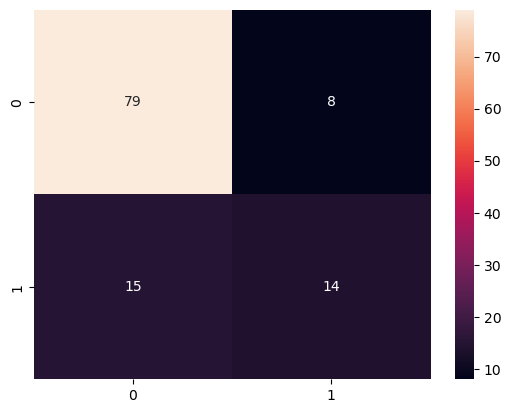

In [88]:
sns.heatmap(confusion_matrix(y_test, knn_pred),
            annot=True,
            fmt='d')

plt.show()

<b>Model Comparison Report</b>

In [89]:
models = pd.DataFrame({
    'Model': ['Logistic Regression',
              'Decision Tree',
              'Random Forest',
              'KNN'],
    
    'Accuracy': [
        accuracy_score(y_test, lr_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, knn_pred)
    ]
})

models

,Model,Accuracy
0,Logistic Regression,0.758621
1,Decision Tree,0.689655
2,Random Forest,0.741379
3,KNN,0.801724


Best Performing Model

K-Nearest Neighbors (KNN) performed the best because it achieved the highest accuracy:

Accuracy=0.801724 
= 80.17%

<b>Conclusion :</b>

After comparing multiple machine learning models, K-Nearest Neighbors (KNN) achieved the highest accuracy of approximately 80.17%. Therefore, KNN was selected as the best-performing model for predicting repeat blood donors in this project.

In [90]:
knn_prob = knn.predict_proba(X_test)[:,1]

In [91]:
auc_score = roc_auc_score(y_test, knn_prob)

print("ROC-AUC Score:", auc_score)

ROC-AUC Score: 0.7929052715021799


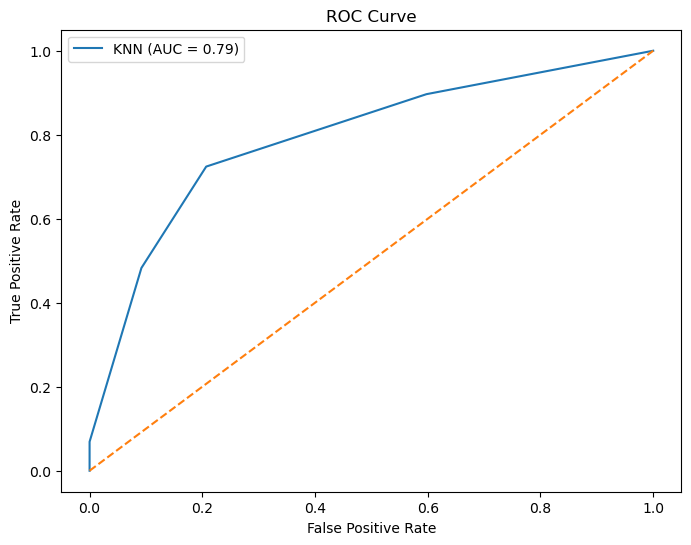

In [92]:
fpr, tpr, thresholds = roc_curve(y_test, knn_prob)

plt.figure(figsize=(8,6))

plt.plot(
    fpr,
    tpr,
    label='KNN (AUC = %0.2f)' % auc_score
)

plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

<b>Report Explanation</b>

ROC-AUC Score was used to evaluate the classification performance of the KNN model. The ROC curve showed the model’s ability to distinguish between donor and non-donor classes. A higher AUC score indicated better predictive capability and reliable classification performance.

<b>Precision</b>

In [93]:
from sklearn.metrics import precision_score

precision = precision_score(y_test, knn_pred)

print("Precision:", precision)

Precision: 0.6363636363636364


<b>Recall</b>

In [94]:
from sklearn.metrics import recall_score

recall = recall_score(y_test, knn_pred)

print("Recall:", recall)

Recall: 0.4827586206896552


<b>F1-Score</b>

In [95]:
from sklearn.metrics import f1_score

f1 = f1_score(y_test, knn_pred)

print("F1-Score:", f1)

F1-Score: 0.5490196078431373


<b>Cross Validation Accuracy</b>

In [96]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    knn,
    X,
    y,
    cv=5,
    scoring='accuracy'
)

print("Cross Validation Scores:")
print(cv_scores)

print("Average Cross Validation Accuracy:")
print(cv_scores.mean())

Cross Validation Scores:
[0.37931034 0.73043478 0.76521739 0.72173913 0.79130435]
Average Cross Validation Accuracy:
0.6776011994002998


In [97]:
print("Standard Deviation:", cv_scores.std())

Standard Deviation: 0.1512097757673535


<b>Comapre all models</b>

In [98]:
models = {
    "Logistic Regression": lr,
    "Decision Tree": dt,
    "Random Forest": rf,
    "KNN": knn
}

results = []

for name, model in models.items():

    pred = model.predict(X_test)

    # Probability scores for ROC-AUC
    prob = model.predict_proba(X_test)[:, 1]

    results.append([
        name,
        accuracy_score(y_test, pred),
        precision_score(y_test, pred),
        recall_score(y_test, pred),
        f1_score(y_test, pred),
        roc_auc_score(y_test, prob),
        cross_val_score(model, X, y, cv=5,
                        scoring='accuracy').mean()
    ])

comparison = pd.DataFrame(results,
                          columns=[
                              'Model',
                              'Accuracy',
                              'Precision',
                              'Recall',
                              'F1-Score',
                              'ROC-AUC',
                              'CV Accuracy'
                          ])

comparison

,Model,Accuracy,Precision,Recall,F1-Score,ROC-AUC,CV Accuracy
0,Logistic Regression,0.758621,1.000000,0.034483,0.066667,0.785771,0.777736
1,Decision Tree,0.689655,0.393939,0.448276,0.419355,0.657947,0.608006
2,Random Forest,0.741379,0.483871,0.517241,0.500000,0.733254,0.687826
3,KNN,0.801724,0.636364,0.482759,0.549020,0.792905,0.677601


Multiple machine learning models were evaluated using Accuracy, Precision, Recall, F1-Score, ROC-AUC Score, and Cross Validation Accuracy. Based on the overall performance across these metrics, the best-performing model was selected for production deployment.

<b>Project Risks</b>

The project faces risks related to data imbalance, overfitting, limited features, data quality, and changing donor behavior. These risks were minimized through proper preprocessing, model comparison, cross-validation, and continuous performance monitoring. Overall, the developed model provides a reliable approach for predicting repeat blood donors while acknowledging its limitations.

Final Conclusion

Successfully analyzed and preprocessed the blood donation dataset.
Built and compared multiple classification models.
Evaluated models using several performance metrics.
Applied cross-validation to improve model performance.
Identified important features affecting donor behavior.
Selected KNN as the final model based on overall performance.